# Tracking, Evolution, and Ellipse fit of the Eddy Using SWOT SLA

## Goal of the Notebook

This notebook aims at studying eddy propagation and evolution through contours: we extract SLA contours from SWOT, fit ellipses to quantify eddy shape and position over time. The resulting ellipses are meant to be interpreted as compact geometric descriptor of the SLA anomaly and serve as schematics of the evolution of the eddy along Algerian Coast.

## Data

To download the data see the README.md. The user will need to define the paths of the data directories of the folder(s) which holds the data and the data directory of the folder where the fitted ellipses models will be saved (important for the notebook "figure6").

## Import modules and open datasets

In [1]:
### IMPORT MODULES ###

import os
from glob import glob
import gc  
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import xarray as xr
import scipy.io
import cartopy
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patheffects as path_effects
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.signal import butter, filtfilt
from scipy.interpolate import griddata, interp1d
from shapely.geometry import MultiPoint
from shapely.ops import unary_union, polygonize
from scipy.spatial import Delaunay
from skimage.measure import EllipseModel
from skimage import measure
import geopy.distance
from datetime import datetime, timedelta

In [2]:
### BATHYMETRY ###

datadir_bathy = '/Users/martina/ex_tesi/datasets/bathymetry/'

ds_bathy=xr.open_dataset(datadir_bathy+'MED_GEBCO_30sec.nc')

For SWOT data, it was decided to separate the data in 4 groups in order to facilitate the preprocessing, based on the month (may, june) and on the pass (right n. 003, left n. 016):

- May, right pass
- May, left pass
- June, right pass
- June, left pass

In [3]:
### SWOT ###

# Directories
datadir_may_right= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/003_may/'
datadir_june_right= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/003_june/'
datadir_may_left= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/016_may/'
datadir_june_left= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/016_june/'

# Dictionary
datasets_may_right = {}
datasets_may_left = {}
datasets_june_right = {}
datasets_june_left = {}

# May right
may_files_right = sorted(glob(os.path.join(datadir_may_right, 'SWOT_L3_LR_SSH_Expert_*_003_202305*_v2.0.1.nc')))
for f in may_files_right:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_003_{date_tag[4:]}"  # -> 'ds_003_0501'
    datasets_may_right[key] = xr.open_dataset(f)

# June right
june_files_right = sorted(glob(os.path.join(datadir_june_right, 'SWOT_L3_LR_SSH_Expert_*_003_202306*_v2.0.1.nc')))
for f in june_files_right:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_003_{date_tag[4:]}"  # -> 'ds_003_0601'
    datasets_june_right[key] = xr.open_dataset(f)

# May left
may_files_left = sorted(glob(os.path.join(datadir_may_left, 'SWOT_L3_LR_SSH_Expert_*_016_202305*_v2.0.1.nc')))
for f in may_files_left:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_016_{date_tag[4:]}"  # -> 'ds_016_0501'
    datasets_may_left[key] = xr.open_dataset(f)

# June left
june_files_left = sorted(glob(os.path.join(datadir_june_left, 'SWOT_L3_LR_SSH_Expert_*_016_202306*_v2.0.1.nc')))
for f in june_files_left:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_016_{date_tag[4:]}"  # -> 'ds_016_0601'
    datasets_june_left[key] = xr.open_dataset(f)

In [4]:
### SWOT NADIR AND SWATHS ###

## Load MAT file
datadir_swot='/Users/martina/ex_tesi/SWOT_coordinates/'
nadir = scipy.io.loadmat(datadir_swot+'swot_calval_hr_Dec2022-v07-nadir.mat')
swath = scipy.io.loadmat(datadir_swot+'swot_calval_hr_Dec2022-v07-swath.mat')

## Print out variable names of file nadir
print("Variable names in the MAT file:")
for key in nadir:
    print(key)

# Access variables in nadir
variable1 = nadir['__header__']
variable2 = nadir['__version__']
variable3 = nadir['__globals__']
variable4 = nadir['lonlat_swot_track_nadir']

## Print out variable names of file swath
print("Variable names in the MAT file:")
for key in swath:
    print(key)

# Access variables in swath
variable5 = swath['__header__']
variable6 = swath['__version__']
variable7 = swath['__globals__']
variable8 = swath['lonlat_swot_track_swath']



# Define latitude and longitude bounds
lat_min, lat_max = 36, 42
lon_min, lon_max = -2, 8

##NADIR

# Extract latitude and longitude data from variable4

lat_nadir = variable4[:, 1]
lon_nadir = variable4[:, 0]


# Initialize empty lists to store filtered latitude and longitude points
filtered_latitudes = []
filtered_longitudes = []

# Loop through latitude and longitude arrays and select points within bounds
for lat, lon in zip(lat_nadir, lon_nadir):
    if lat >= lat_min and lat <= lat_max and lon >= lon_min and lon <= lon_max:
        filtered_latitudes.append(lat)
        filtered_longitudes.append(lon)


#nadir1
selected_lat_nadir1 = filtered_latitudes[:10]
selected_lon_nadir1 = filtered_longitudes[:10]

#nadir2
selected_lat_nadir2 = filtered_latitudes[10:20]
selected_lon_nadir2 = filtered_longitudes[10:20]  

##SWATH

# Extract latitude and longitude data from variable8

lat_swath = variable8[:, 1]
lon_swath = variable8[:, 0]

# Initialize empty lists to store filtered latitude and longitude points
filtered_latitudes_swath = []
filtered_longitudes_swath = []

# Loop through latitude and longitude arrays and select points within bounds
for lat, lon in zip(lat_swath, lon_swath):
    if lat >= lat_min and lat <= lat_max and lon >= lon_min and lon <= lon_max:
        filtered_latitudes_swath.append(lat)
        filtered_longitudes_swath.append(lon)


selected_lat_swath1 = filtered_latitudes_swath[:10]
selected_lon_swath1 = filtered_longitudes_swath[:10]

selected_lat_swath2 = filtered_latitudes_swath[10:20]
selected_lon_swath2 = filtered_longitudes_swath[10:20]

selected_lat_swath3 = filtered_latitudes_swath[20:30]
selected_lon_swath3 = filtered_longitudes_swath[20:30]

selected_lat_swath4 = filtered_latitudes_swath[31:41]
selected_lon_swath4 = filtered_longitudes_swath[31:41]

selected_lat_swath5 = filtered_latitudes_swath[41:51] 
selected_lon_swath5 = filtered_longitudes_swath[41:51]

selected_lat_swath6 = filtered_latitudes_swath[52:62]
selected_lon_swath6 = filtered_longitudes_swath[52:62]

selected_lat_swath7 = filtered_latitudes_swath[62:72]
selected_lon_swath7 = filtered_longitudes_swath[62:72]

selected_lat_swath8 = filtered_latitudes_swath[72:82]
selected_lon_swath8 = filtered_longitudes_swath[72:82]


Variable names in the MAT file:
__header__
__version__
__globals__
lonlat_swot_track_nadir
Variable names in the MAT file:
__header__
__version__
__globals__
lonlat_swot_track_swath


## Preprocessing of the datasets

### Crop SWOT datasets to the area of interest

In [5]:
# Area of interest 
lon_min, lon_max = 1, 5
lat_min, lat_max = 36, 39.5

# Dictionaries for cropped datasets
coastal_may_right = {}
coastal_may_left = {}
coastal_june_right = {}
coastal_june_left = {}

In [6]:
### Function to crop the datasets to the area of interest ###
def crop_datasets(datasets, lon_min, lon_max, lat_min, lat_max):
    cropped_dict = {}
    for key, ds in datasets.items():
        cropped = ds.where(
            (ds['longitude'] > lon_min) & (ds['longitude'] < lon_max) &
            (ds['latitude']  > lat_min) & (ds['latitude']  < lat_max),
            drop=True
        )
        cropped_dict[key] = cropped.load()
        ds.close()
        gc.collect()
    return cropped_dict

In [7]:
# May right
coastal_may_right = crop_datasets(datasets_may_right, lon_min, lon_max, lat_min, lat_max)

In [8]:
# May left
coastal_may_left = crop_datasets(datasets_may_left,  lon_min, lon_max, lat_min, lat_max)

In [9]:
# June right
coastal_june_right = crop_datasets(datasets_june_right, lon_min, lon_max, lat_min, lat_max)

In [10]:
# June left
coastal_june_left = crop_datasets(datasets_june_left,  lon_min, lon_max, lat_min, lat_max)

### Remove mean from SWOT data

In [11]:
### Create ds_* dictionaries with "ssha_filtered" ###

ds_may_right = {}
for key, ds in coastal_may_right.items():
    if key.startswith("ds_003_05"):
        day = key.split("_")[-1]   # es: '0503'
        ds_may_right[f"{day}_r"] = ds["ssha_filtered"]

ds_may_left = {}
for key, ds in coastal_may_left.items():
    if key.startswith("ds_016_05"):
        day = key.split("_")[-1]  
        ds_may_left[f"{day}_l"] = ds["ssha_filtered"]

ds_june_right = {}
for key, ds in coastal_june_right.items():
    if key.startswith("ds_003_06"):
        day = key.split("_")[-1]   
        ds_june_right[f"{day}_r"] = ds["ssha_filtered"]

ds_june_left = {}
for key, ds in coastal_june_left.items():
    if key.startswith("ds_016_06"):
        day = key.split("_")[-1]   
        ds_june_left[f"{day}_l"] = ds["ssha_filtered"]

In [12]:
### Calculate the mean ###
spatial_means_may_right = {k: v.mean(skipna=True) for k, v in ds_may_right.items()}
spatial_means_june_right = {k: v.mean(skipna=True) for k, v in ds_june_right.items()}
spatial_means_may_left = {k: v.mean(skipna=True) for k, v in ds_may_left.items()}
spatial_means_june_left = {k: v.mean(skipna=True) for k, v in ds_june_left.items()}

In [13]:
### Calculate SLA (removing the mean) ###
sla_swot_may_right = {k: ds_may_right[k] - spatial_means_may_right[k] for k in ds_may_right}
sla_swot_june_right = {k: ds_june_right[k] - spatial_means_june_right[k] for k in ds_june_right}
sla_swot_may_left = {k: ds_may_left[k] - spatial_means_may_left[k] for k in ds_may_left}
sla_swot_june_left = {k: ds_june_left[k] - spatial_means_june_left[k] for k in ds_june_left}

### Preprocessing: NaN Inpainting and 2D Butterworth Filtering

In [14]:
### Function to fill NaNs with interpolation ###

def inpaint_nans(data):
    # Get the coordinates of valid (non-NaN) points
    x, y = np.meshgrid(np.arange(data.shape[1]), np.arange(data.shape[0]))
    valid_mask = ~np.isnan(data)
    coords_valid = np.array([x[valid_mask], y[valid_mask]]).T
    values_valid = data[valid_mask]
    
    # Get the coordinates of NaN points that need to be interpolated
    coords_nan = np.array([x[np.isnan(data)], y[np.isnan(data)]]).T
    # Create an output array and fill NaNs with interpolated values
    data_inpainted = data.copy()
    data_inpainted[np.isnan(data)] = griddata(coords_valid, values_valid, coords_nan, method='nearest')
    
    return data_inpainted

In [15]:
### Function to apply a 1D filter along a specific axis ###

def filter_1d_along_axis(dati, b, a, asse, pad_width=4):
    # Mask of valid (non-NaN) values
    valid_mask = ~np.isnan(dati)  
    # Temporarily replace NaNs with zeros to avoid propagation during filtering
    dati_validi = np.where(valid_mask, dati, 0)  
    
    # Apply reflective padding along the selected axis
    dati_padded = np.pad(dati_validi, [(pad_width, pad_width) if i == asse else (0, 0) for i in range(dati.ndim)], mode='edge')
    
    # Apply filtfilt along the chosen axis
    dati_filtrati_padded = np.apply_along_axis(lambda m: filtfilt(b, a, m), axis=asse, arr=dati_padded)
    
    # Remove the padding after filtering
    dati_filtrati = dati_filtrati_padded[pad_width:-pad_width] if asse == 0 else dati_filtrati_padded[:, pad_width:-pad_width]
    
    # Restore NaNs in their original positions
    return np.where(valid_mask, dati_filtrati, np.nan)

In [16]:
### Function to apply the filter ### 

def apply_butter(int_ssha, order, cutoff_frequency, pad_width=4):
    # Estraggo i dati come array NumPy
    ssha_data = int_ssha.values
    
    # Riempio i NaN usando l'inpainting
    data_inpainted = inpaint_nans(ssha_data)
    
    # Calcolo i coefficienti del filtro Butterworth
    b, a = butter(order, cutoff_frequency, btype='low', fs=1.0)

    # Filtrare lungo l'asse x (longitudine) con padding
    dati_filtrati_x = filter_1d_along_axis(data_inpainted, b, a, asse=1, pad_width=pad_width)

    # Filtrare lungo l'asse y (latitudine) con padding
    dati_filtrati_xy = filter_1d_along_axis(dati_filtrati_x, b, a, asse=0, pad_width=pad_width)

    # Ripristino i NaN nelle posizioni originali
    dati_filtrati_xy[np.isnan(ssha_data)] = np.nan

    # Ricreo un DataArray con i dati filtrati
    ssha_filtrato = xr.DataArray(dati_filtrati_xy, dims=int_ssha.dims, coords=int_ssha.coords)
    
    return ssha_filtrato

# Parameters
cutoff_frequency = 0.03  ### 1/0.03 = 33 km 
order = 2

In [17]:
### Apply the filter ###
ssha_filtrato_508_l = apply_butter(sla_swot_may_left['0508_l'], order, cutoff_frequency)
ssha_filtrato_510_l = apply_butter(sla_swot_may_left['0510_l'], order, cutoff_frequency)
ssha_filtrato_511_l = apply_butter(sla_swot_may_left['0511_l'], order, cutoff_frequency)
ssha_filtrato_512_l = apply_butter(sla_swot_may_left['0512_l'], order, cutoff_frequency)
ssha_filtrato_513_l = apply_butter(sla_swot_may_left['0513_l'], order, cutoff_frequency)
ssha_filtrato_514_l = apply_butter(sla_swot_may_left['0514_l'], order, cutoff_frequency)
ssha_filtrato_516_l = apply_butter(sla_swot_may_left['0516_l'], order, cutoff_frequency)
ssha_filtrato_518_l = apply_butter(sla_swot_may_left['0518_l'], order, cutoff_frequency)
ssha_filtrato_519_l = apply_butter(sla_swot_may_left['0519_l'], order, cutoff_frequency)
ssha_filtrato_523_l = apply_butter(sla_swot_may_left['0523_l'], order, cutoff_frequency)
ssha_filtrato_524_l = apply_butter(sla_swot_may_left['0524_l'], order, cutoff_frequency)
ssha_filtrato_525_l = apply_butter(sla_swot_may_left['0525_l'], order, cutoff_frequency)
ssha_filtrato_529_l = apply_butter(sla_swot_may_left['0529_l'], order, cutoff_frequency)
ssha_filtrato_531_l = apply_butter(sla_swot_may_left['0531_l'], order, cutoff_frequency)
ssha_filtrato_601_r = apply_butter(ds_june_right['0601_r'], order, cutoff_frequency)
ssha_filtrato_603_r = apply_butter(ds_june_right['0603_r'], order, cutoff_frequency)
ssha_filtrato_604_r = apply_butter(ds_june_right['0604_r'], order, cutoff_frequency)
ssha_filtrato_605_r = apply_butter(ds_june_right['0605_r'], order, cutoff_frequency)
ssha_filtrato_607_r = apply_butter(ds_june_right['0607_r'], order, cutoff_frequency)
ssha_filtrato_609_r = apply_butter(ds_june_right['0609_r'], order, cutoff_frequency)
ssha_filtrato_610_r = apply_butter(ds_june_right['0610_r'], order, cutoff_frequency)
ssha_filtrato_611_r = apply_butter(ds_june_right['0611_r'], order, cutoff_frequency)
ssha_filtrato_612_r = apply_butter(ds_june_right['0612_r'], order, cutoff_frequency)
ssha_filtrato_613_r = apply_butter(ds_june_right['0613_r'], order, cutoff_frequency)


### Interpolation of ellipses on swot contours

In [18]:
### Function for contour extraction from filtered SLA fields ###
def extract_contour(ds, target_level, tolerance = 0.005):
    
    mask = np.abs(ds - target_level) < tolerance
    masked = ds.where(mask, drop=True)

    return masked

In [19]:
### Extract contours ### 
masked_508_l = extract_contour(ssha_filtrato_508_l, 0.055)
masked_510_l = extract_contour(ssha_filtrato_510_l, 0.04)
masked_511_l = extract_contour(ssha_filtrato_511_l, 0.04)
masked_512_l = extract_contour(ssha_filtrato_512_l, 0.035)
masked_513_l = extract_contour(ssha_filtrato_513_l, 0.05)
masked_514_l = extract_contour(ssha_filtrato_514_l, 0.04)
masked_516_l = extract_contour(ssha_filtrato_516_l, 0.045)
masked_518_l = extract_contour(ssha_filtrato_518_l, 0.05)
masked_519_l = extract_contour(ssha_filtrato_519_l, 0.045)
masked_523_l = extract_contour(ssha_filtrato_523_l, 0.035)
masked_524_l = extract_contour(ssha_filtrato_524_l, 0.035)
masked_525_l = extract_contour(ssha_filtrato_525_l, 0.005)
masked_529_l = extract_contour(ssha_filtrato_529_l, 0.005)
masked_531_l = extract_contour(ssha_filtrato_531_l, 0.016)
masked_601_r = extract_contour(ssha_filtrato_601_r, 0.12)
masked_603_r = extract_contour(ssha_filtrato_603_r, 0.085)
masked_604_r = extract_contour(ssha_filtrato_604_r, 0.11)
masked_605_r = extract_contour(ssha_filtrato_605_r, 0.106)
masked_607_r = extract_contour(ssha_filtrato_607_r, 0.14)
masked_609_r = extract_contour(ssha_filtrato_609_r, 0.1)
masked_610_r = extract_contour(ssha_filtrato_610_r, 0.10)
masked_611_r = extract_contour(ssha_filtrato_611_r, 0.105)
masked_612_r = extract_contour(ssha_filtrato_612_r, 0.12)
masked_613_r = extract_contour(ssha_filtrato_613_r, 0.15)


In [20]:
### Function to extract valid (non-NaN) points from a DataArray ###
def extract_valid_points(da):
    # Extract latitude and longitude coordinates
    lat = da['latitude'].values
    lon = da['longitude'].values
    # Create a mask selecting only non-NaN data values
    mask = ~np.isnan(da.values)
    return lon[mask], lat[mask]

In [21]:
### Function to compute the boundary using an alpha shape ###
def alpha_shape(points, alpha):
    if len(points) < 4:
        return MultiPoint(points).convex_hull

    def add_edge(edges, coords, i, j):
        if (i, j) in edges or (j, i) in edges:
            return
        edges.add((i, j))
        edges_coords.append(coords[[i, j]])

    # Perform Delaunay triangulation on the input point cloud
    tri = Delaunay(points) 
    edges = set()
    edges_coords = []
    # Loop over triangles generated by Delaunay triangulation
    for ia, ib, ic in tri.simplices:
        pa, pb, pc = points[ia], points[ib], points[ic]
        # Compute triangle side lengths
        a = np.linalg.norm(pa - pb)
        b = np.linalg.norm(pb - pc)
        c = np.linalg.norm(pc - pa)
        s = (a + b + c) / 2.0
        # Compute triangle area (Heron's formula)
        area = np.sqrt(s * (s - a) * (s - b) * (s - c))
        # Radius of the circumcircle
        circum_r = a * b * c / (4.0 * area)
        # Keep triangles whose circumradius satisfies alpha criterion
        if circum_r < 1.0 / alpha:
            add_edge(edges, points, ia, ib)
            add_edge(edges, points, ib, ic)
            add_edge(edges, points, ic, ia)
    # Convert the selected edges into polygons and merge them
    m = MultiPoint(points)
    triangles = [polygon for polygon in polygonize(edges_coords)]
    return unary_union(triangles).boundary

In [22]:
### Function to fit an ellipse to a set of boundary points ###
def fit_ellipse(points):
    model = EllipseModel()
    if not model.estimate(points):
        raise ValueError("Fit failed.")
    return model

In [23]:
### Ensuring correct eddy contour for ellipse fitting ###

north_lim = 37.6
masked_510_l_cut = masked_510_l.where(masked_510_l['longitude'] < 3, drop=True)
masked_512_l_cut = masked_512_l.where(masked_512_l['latitude'] < north_lim, drop=True)
masked_523_l_cut = masked_523_l.where(masked_523_l['latitude'] < north_lim, drop=True)
masked_524_l_cut = masked_524_l.where(masked_524_l['latitude'] < north_lim, drop=True)
masked_525_l_cut = masked_525_l.where((masked_525_l['latitude'] < north_lim) & (masked_525_l['longitude'] > 2.8), drop=True)
masked_529_l_cut = masked_529_l.where((masked_529_l['latitude'] < north_lim) & (masked_529_l['longitude'] > 2.7), drop=True)
masked_531_l_cut = masked_531_l.where((masked_531_l['latitude'] < north_lim) & (masked_531_l['longitude'] > 2.7), drop=True)
masked_601_r_cut = masked_601_r.where((masked_601_r['latitude'] < north_lim) & (masked_601_r['latitude'] > 36.1), drop=True)
masked_603_r_cut = masked_603_r.where((masked_603_r['latitude'] < north_lim) & (masked_603_r['longitude'] > 3.5), drop=True)
masked_604_r_cut = masked_604_r.where((masked_604_r['latitude'] < north_lim), drop=True)
masked_605_r_cut = masked_605_r.where((masked_605_r['latitude'] < north_lim), drop=True)
masked_609_r_cut = masked_609_r.where((masked_609_r['latitude'] < north_lim) & (masked_609_r['longitude'] > 3.5), drop=True)
masked_610_r_cut = masked_610_r.where(masked_610_r['latitude'] < north_lim, drop=True)
masked_607_r_cut = masked_607_r.where((masked_607_r['latitude'] < north_lim) & (masked_607_r['longitude'] > 3.5), drop=True)
masked_611_r_cut = masked_611_r.where((masked_611_r['latitude'] < north_lim) & (masked_611_r['longitude'] > 3.5), drop=True)
masked_612_r_cut = masked_612_r.where((masked_612_r['latitude'] < north_lim) & (masked_612_r['longitude'] > 3.6), drop=True)
masked_613_r_cut = masked_613_r.where((masked_613_r['latitude'] < north_lim) & (masked_613_r['longitude'] > 3.9), drop=True)

The contour selection was spatially restricted to avoid contamination from adjacent structures and to ensure that the ellipse fitting was applied to the same propagating eddy throughout the analysis.

In [24]:
### Coordinates extraction ###

lon_508_l, lat_508_l = extract_valid_points(masked_508_l)
lon_510_l, lat_510_l = extract_valid_points(masked_510_l_cut)
lon_511_l, lat_511_l = extract_valid_points(masked_511_l)
lon_512_l, lat_512_l = extract_valid_points(masked_512_l_cut)
lon_513_l, lat_513_l = extract_valid_points(masked_513_l)
lon_514_l, lat_514_l = extract_valid_points(masked_514_l)
lon_516_l, lat_516_l = extract_valid_points(masked_516_l)
lon_518_l, lat_518_l = extract_valid_points(masked_518_l)
lon_519_l, lat_519_l = extract_valid_points(masked_519_l)
lon_523_l, lat_523_l = extract_valid_points(masked_523_l_cut)
lon_524_l, lat_524_l = extract_valid_points(masked_524_l_cut)
lon_525_l, lat_525_l = extract_valid_points(masked_525_l_cut)
lon_529_l, lat_529_l = extract_valid_points(masked_529_l_cut)
lon_531_l, lat_531_l = extract_valid_points(masked_531_l_cut)
lon_601_r, lat_601_r = extract_valid_points(masked_601_r_cut)
lon_603_r, lat_603_r = extract_valid_points(masked_603_r_cut)
lon_604_r, lat_604_r = extract_valid_points(masked_604_r_cut)
lon_605_r, lat_605_r = extract_valid_points(masked_605_r_cut)
lon_607_r, lat_607_r = extract_valid_points(masked_607_r_cut)
lon_609_r, lat_609_r = extract_valid_points(masked_609_r_cut)
lon_610_r, lat_610_r = extract_valid_points(masked_610_r_cut)
lon_611_r, lat_611_r = extract_valid_points(masked_611_r_cut)
lon_612_r, lat_612_r = extract_valid_points(masked_612_r_cut)
lon_613_r, lat_613_r = extract_valid_points(masked_613_r_cut)

In [25]:
### Create points arrays ###

points_508_l = np.column_stack((lon_508_l, lat_508_l))
points_510_l = np.column_stack((lon_510_l, lat_510_l))
points_511_l = np.column_stack((lon_511_l, lat_511_l))
points_512_l = np.column_stack((lon_512_l, lat_512_l))
points_513_l = np.column_stack((lon_513_l, lat_513_l))
points_514_l = np.column_stack((lon_514_l, lat_514_l))
points_516_l = np.column_stack((lon_516_l, lat_516_l))
points_518_l = np.column_stack((lon_518_l, lat_518_l))
points_519_l = np.column_stack((lon_519_l, lat_519_l))
points_523_l = np.column_stack((lon_523_l, lat_523_l))
points_525_l = np.column_stack((lon_525_l, lat_525_l))
points_524_l = np.column_stack((lon_524_l, lat_524_l))
points_529_l = np.column_stack((lon_529_l, lat_529_l))
points_531_l = np.column_stack((lon_531_l, lat_531_l))
points_601_r = np.column_stack((lon_601_r, lat_601_r))
points_603_r = np.column_stack((lon_603_r, lat_603_r))
points_604_r = np.column_stack((lon_604_r, lat_604_r))
points_605_r = np.column_stack((lon_605_r, lat_605_r))
points_607_r = np.column_stack((lon_607_r, lat_607_r))
points_609_r = np.column_stack((lon_609_r, lat_609_r))
points_610_r = np.column_stack((lon_610_r, lat_610_r))
points_611_r = np.column_stack((lon_611_r, lat_611_r))
points_612_r = np.column_stack((lon_612_r, lat_612_r))
points_613_r = np.column_stack((lon_613_r, lat_613_r))

In [26]:
### Contour extraction ###

contour_508_l = alpha_shape(points_508_l, alpha=0.01)
contour_coords_508_l = np.array(contour_508_l.coords)

contour_510_l = alpha_shape(points_510_l, alpha=0.01)
contour_coords_510_l = np.array(contour_510_l.coords)

contour_511_l = alpha_shape(points_511_l, alpha=0.01)
contour_coords_511_l = np.array(contour_511_l.coords)

contour_512_l = alpha_shape(points_512_l, alpha=0.01)
contour_coords_512_l = np.array(contour_512_l.coords)

contour_513_l = alpha_shape(points_513_l, alpha=0.01)
contour_coords_513_l = np.array(contour_513_l.coords)

contour_514_l = alpha_shape(points_514_l, alpha=0.01)
contour_coords_514_l = np.array(contour_514_l.coords)

contour_516_l = alpha_shape(points_516_l, alpha=0.01)
contour_coords_516_l = np.array(contour_516_l.coords)

contour_518_l = alpha_shape(points_518_l, alpha=0.01)
contour_coords_518_l = np.array(contour_518_l.coords)

contour_519_l = alpha_shape(points_519_l, alpha=0.01)
contour_coords_519_l = np.array(contour_519_l.coords)

contour_523_l = alpha_shape(points_523_l, alpha=0.01)
contour_coords_523_l = np.array(contour_523_l.coords)

contour_524_l = alpha_shape(points_524_l, alpha=0.01)
contour_coords_524_l = np.array(contour_524_l.coords)

contour_525_l = alpha_shape(points_525_l, alpha=0.01)
contour_coords_525_l = np.array(contour_525_l.coords)

contour_529_l = alpha_shape(points_529_l, alpha=0.01)
contour_coords_529_l = np.array(contour_529_l.coords)

contour_531_l = alpha_shape(points_531_l, alpha=0.1)
contour_coords_531_l = np.array(contour_531_l.coords)

contour_601_r = alpha_shape(points_601_r, alpha=0.01)
contour_coords_601_r = np.array(contour_601_r.coords)

contour_603_r = alpha_shape(points_603_r, alpha=0.01)
contour_coords_603_r = np.array(contour_603_r.coords)

contour_604_r = alpha_shape(points_604_r, alpha=0.1)
contour_coords_604_r = np.array(contour_604_r.coords)

contour_605_r = alpha_shape(points_605_r, alpha=0.1)
contour_coords_605_r = np.array(contour_605_r.coords)

contour_607_r = alpha_shape(points_607_r, alpha=0.01)
contour_coords_607_r = np.array(contour_607_r.coords)

contour_609_r = alpha_shape(points_609_r, alpha=0.1)
contour_coords_609_r = np.array(contour_609_r.coords)

contour_610_r = alpha_shape(points_610_r, alpha=0.01)
contour_coords_610_r = np.array(contour_610_r.coords)

contour_611_r = alpha_shape(points_611_r, alpha=0.01)
contour_coords_611_r = np.array(contour_611_r.coords)

contour_612_r = alpha_shape(points_612_r, alpha=0.1)
contour_coords_612_r = np.array(contour_612_r.coords)

contour_613_r = alpha_shape(points_613_r, alpha=0.01)
contour_coords_613_r = np.array(contour_613_r.coords)

In [ ]:
### Fit ellipses to the contours ###

model_508_l = fit_ellipse(contour_coords_508_l)
model_510_l = fit_ellipse(contour_coords_510_l)
model_511_l = fit_ellipse(contour_coords_511_l)
model_512_l = fit_ellipse(contour_coords_512_l)
model_513_l = fit_ellipse(contour_coords_513_l)
model_514_l = fit_ellipse(contour_coords_514_l)
model_516_l = fit_ellipse(contour_coords_516_l)
model_518_l = fit_ellipse(contour_coords_518_l)
model_519_l =fit_ellipse(contour_coords_519_l)
model_523_l = fit_ellipse(contour_coords_523_l)
model_524_l = fit_ellipse(contour_coords_524_l)
model_525_l = fit_ellipse(contour_coords_525_l)
model_529_l = fit_ellipse(contour_coords_529_l)
model_531_l = fit_ellipse(contour_coords_531_l)
model_601_r = fit_ellipse(contour_coords_601_r)
model_603_r = fit_ellipse(contour_coords_603_r)
model_604_r = fit_ellipse(contour_coords_604_r)
model_605_r = fit_ellipse(contour_coords_605_r)
model_607_r = fit_ellipse(contour_coords_607_r)
model_609_r = fit_ellipse(contour_coords_609_r)
model_610_r = fit_ellipse(contour_coords_610_r)
model_611_r = fit_ellipse(contour_coords_611_r)
model_612_r = fit_ellipse(contour_coords_612_r)
model_613_r = fit_ellipse(contour_coords_613_r)

In [39]:
### Save a file with the fitted ellipses ###

all_models = {
    "508_l": model_508_l,
    "510_l": model_510_l,
    "511_l": model_511_l,
    "512_l": model_512_l,
    "513_l": model_513_l,
    "514_l": model_514_l,
    "516_l": model_516_l,
    "518_l": model_518_l,
    "519_l": model_519_l,
    "523_l": model_523_l,
    "524_l": model_524_l,
    "525_l": model_525_l,
    "529_l": model_529_l,
    "531_l": model_531_l,
    "601_r": model_601_r,
    "603_r": model_603_r,
    "604_r": model_604_r,
    "605_r": model_605_r,
    "607_r": model_607_r,
    "609_r": model_609_r,
    "610_r": model_610_r,
    "611_r": model_611_r,
    "612_r": model_612_r,
    "613_r": model_613_r,
}

save_dir = "/Users/martina/ex_tesi/Notebooks/results_ellipsefit"

for name, model in all_models.items():
    path = os.path.join(save_dir, f"ellipse_{name}.npy")
    np.save(path, model.params)

In [28]:
### Function for plotting fitted ellipses on map ###
def plot_ellipse_on_map(ax, model, color, label=None):
    xc, yc, a, b, theta = model.params
    t = np.linspace(0, 2 * np.pi, 500)
    ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
    ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
    ax.plot(ellipse_x, ellipse_y, color=color, lw=3, transform=ccrs.PlateCarree(), label=label)

In [29]:
# Ellipse models used in the plot
ellipse_models = [
    model_508_l, model_511_l, model_516_l, model_523_l, model_525_l,
    model_529_l, model_531_l, model_604_r, model_605_r,
    model_609_r, model_612_r
]

# Dates Corresponding to the Fitted Ellipses
contour_dates_dt = [
    datetime(2023, 5, 8),
    datetime(2023, 5, 11),
    datetime(2023, 5, 16),
    datetime(2023, 5, 23),
    datetime(2023, 5, 25),
    datetime(2023, 5, 29),
    datetime(2023, 5, 31),
    datetime(2023, 6, 4),
    datetime(2023, 6, 5),
    datetime(2023, 6, 9),
    datetime(2023, 6, 12),
]

# Final Figure: Schematics of Eddy Evolution and Propagation

In [30]:
# Create colormap (one color per observation date)
cmap = plt.cm.get_cmap('turbo', len(contour_dates_dt))  # 11 colori
bounds = np.linspace(0, len(contour_dates_dt), len(contour_dates_dt) + 1)
norm = BoundaryNorm(bounds, ncolors=len(contour_dates_dt))

In [31]:
### Extract elevation from bathymetry dataset ###
bathymetry = ds_bathy['elevation'].values
lat = ds_bathy['lat'].values
lon = ds_bathy['lon'].values

In [32]:
### Define the date range for the calculation of velocities ###
date_ranges = [('5-08', '5-10'), ('5-10', '5-11'), ('5-11', '5-12'),
                          ('5-12', '5-13'), ('5-13', '5-14'), ('5-14', '5-16'),
                          ('5-16', '5-18'), ('5-18', '5-19'), ('5-19', '5-23'),
                          ('5-23', '5-24'), ('5-24', '5-25'), 
                          ('5-25', '5-29'), ('5-29', '5-31'), ('5-31', '6-01'),
                          ('6-01', '6-03'), ('6-03', '6-07'), ('6-07', '6-09'),
                          ('6-09', '6-10'), ('6-10', '6-11'), ('6-11', '6-12'),
                          ('6-12', '6-13')]

dates = [(datetime.strptime(start, "%m-%d") + (datetime.strptime(end, "%m-%d") - datetime.strptime(start, "%m-%d")) / 2)
                 for start, end in date_ranges]

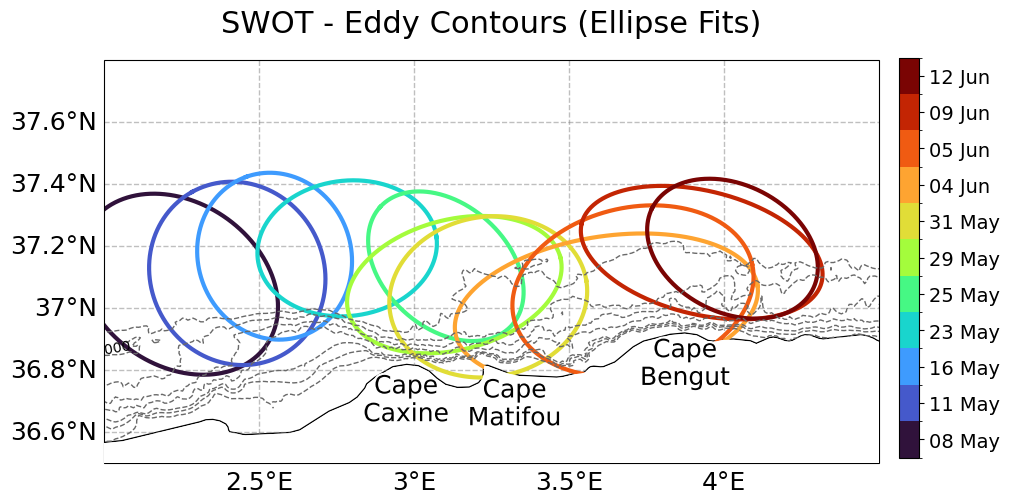

In [33]:
fig, ax2 = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 8))


ax2.set_extent([2, 4.5, 36.5, 37.8], crs=ccrs.PlateCarree())
ax2.coastlines(resolution='10m', color='k', linewidth=2)
ax2.add_feature(cartopy.feature.LAND, facecolor='white', zorder=10)
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')   
gl.xlabel_style = {'size': 18}
gl.ylabel_style = {'size': 18}
gl.right_labels = False; gl.top_labels = False
ax2.add_feature(cartopy.feature.LAND, facecolor='white', zorder=10) 

# Plot all fitted ellipses with color-coded temporal sequence
for i, model in enumerate(ellipse_models):
    color = cmap(norm(i))
    plot_ellipse_on_map(ax2, model, color=color)

#  Bathymetry contours
contour = ax2.contour(lon, lat, bathymetry, levels=[-2500, -2000, -1500, -1000, -500, -350, -200],
                     colors='dimgray', linewidths=1, transform=ccrs.PlateCarree())
ax2.clabel(contour, inline=True, fontsize=10, colors='k')  

# Title
ax2.set_title('SWOT - Eddy Contours (Ellipse Fits)', fontsize=22, pad=20) 

# Colorbar 
cbar_ax2 = fig.add_axes([0.92, 0.25, 0.02, 0.5]) 
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax2, orientation='vertical')
cbar.set_ticks(0.5 + np.arange(len(contour_dates_dt)))
cbar.set_ticklabels([d.strftime('%d %b') for d in contour_dates_dt], rotation=0)
cbar.ax.tick_params(labelsize=14)

# Capes labels
txt1 = ax2.text(0.39, 0.22, 'Cape\nCaxine', transform=ax2.transAxes, fontsize=18, ha='center', va='top', zorder=20, color='k')
txt1.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()])

txt2 = ax2.text(0.53, 0.21, 'Cape\nMatifou', transform=ax2.transAxes, fontsize=18, ha='center', va='top', zorder=20, color='k')
txt2.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()])

txt3 = ax2.text(0.75, 0.31, 'Cape\nBengut', transform=ax2.transAxes, fontsize=18, ha='center', va='top', zorder=20, color='k')
txt3.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()])